# RIS PPO Training — Non-Oracle Observation (Colab / TPU)

**Observation design:** the agent sees only what a real RIS controller has access to:
- Current group phases (sin/cos encoded)
- Current normalised gain: `(gain_db - rand_db) / headroom_db`
- Step fraction `t / T`
- One-hot encoding of which group is being updated

The agent does **not** receive a pre-computed per-group gain table.
It must learn to map from configuration + current channel quality → which phase to set.

**Setup:** N=256 elements, G=4 groups, K=16 phase levels, T=8 steps (2 passes over groups).  
All group phases initialised to 0°. Group update order randomised each episode.

**v8c changes:** N_PASSES=3 (T=12), NOISE_LEVEL=0.1 (~SNR=20dB) wired into observation, UPDATES=3000.  
**v8b changes:** training geometry matched to sweep region (RX x∈[38,62], z∈[-3,3]), UPDATES=2500.  
**v8 changes vs v3:** RX x training range widened [45,55]→[40,55], randomised group order (fixes z asymmetry), UPDATES=2000, random policy baseline added to inference output.

Outputs saved to `/content/ppo_train/`.

In [ ]:
# ===== Mount Google Drive & save model =====

# Mount Drive (will prompt for auth on first run)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.distributions import Categorical

# ===== Physical constants & array geometry =====
c  = 3e8
fc = 28e9
lam = c / fc
Ny, Nz = 16, 16
N = Ny * Nz                          # 256 elements
d_elem = lam / 2
ris_x, ris_y, ris_z = 25.0, 2.0, 0.0

y_pos = (np.arange(Ny) - (Ny - 1) / 2) * d_elem + ris_y
z_pos = (np.arange(Nz) - (Nz - 1) / 2) * d_elem + ris_z
YY, ZZ = np.meshgrid(y_pos, z_pos, indexing='ij')
XX = np.full_like(YY, ris_x)
ris_pos = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=1)  # (N, 3)

# ===== RIS control parameters =====
G = 4                                       # number of groups
K = 16                                      # discrete phase levels per group
N_PASSES = 3                                # refinement passes over all groups
T = G * N_PASSES                            # episode length = 12 steps
phase_levels_deg = np.linspace(0, 360, K, endpoint=False)
n_actions = K
cols_per_group = Nz // G
element_group = np.array([(n % Nz) // cols_per_group for n in range(N)], dtype=int)

# ===== State space =====
# phase_sin[G] + phase_cos[G] + normalised_gain + step_frac + group_onehot[G]
STATE_DIM = 3 * G + 2   # = 14


# =====================================================================
# Channel utilities
# =====================================================================

def compute_channel(tx, rx):
    """Return per-element propagation parameters and analytical optimal gain."""
    d_a = np.linalg.norm(ris_pos - tx, axis=1)
    d_b = np.linalg.norm(ris_pos - rx, axis=1)
    tau_na = d_a / c
    tau_nb = d_b / c
    alpha = (lam / (4 * np.pi * d_a)) ** 2
    beta  = (lam / (4 * np.pi * d_b)) ** 2
    tau_geo = tau_na + tau_nb
    tau_opt = tau_geo.max() - tau_geo       # delay shift for coherent combining
    phi_opt_deg = np.rad2deg(2 * np.pi * fc * tau_opt)
    amp = np.sqrt(alpha * beta)
    phasors = amp * np.exp(-1j * 2 * np.pi * fc * (tau_na + tau_opt + tau_nb))
    gain_opt = float(np.abs(phasors.sum()) ** 2)
    return tau_na, tau_nb, alpha, beta, tau_opt, phi_opt_deg, gain_opt


def channel_gain(tau_na, tau_nb, alpha, beta, tau_theta):
    amp = np.sqrt(alpha * beta)
    phasors = amp * np.exp(-1j * 2 * np.pi * fc * (tau_na + tau_theta + tau_nb))
    return float(np.abs(phasors.sum()) ** 2)


def random_gain(tau_na, tau_nb, alpha, beta, rng, n_samples=50):
    vals = [
        channel_gain(tau_na, tau_nb, alpha, beta, rng.uniform(0, 1 / fc, N))
        for _ in range(n_samples)
    ]
    return float(np.mean(vals))


def config_to_tau(group_phases_deg):
    """Convert per-group phase assignments (degrees) to per-element delay."""
    tau = np.zeros(N)
    for g in range(G):
        idx = element_group == g
        tau[idx] = np.deg2rad(group_phases_deg[g]) / (2 * np.pi * fc)
    return tau


# =====================================================================
# Environment
# =====================================================================

class RISEnv:
    """
    Sequential group-phase optimisation environment.

    Episode structure
    -----------------
    T = G * N_PASSES steps (=12 with N_PASSES=3).  At step t, the agent sets the phase of group
    g = t % G.  Two passes allow refinement once all groups have been
    visited once.

    All group phases start at 0° at the beginning of every episode.

    Observation (STATE_DIM = 3*G+2 = 14)
    -------------------------------------
    [ phase_sin(G), phase_cos(G), norm_gain(1), step_frac(1), group_onehot(G) ]

    * phase_sin / phase_cos: sin/cos of current group phases (geometry-invariant
      encoding of the current configuration).
    * norm_gain: (gain_db - rand_db) / headroom_db, clipped to [-1, 3].
      Tells the agent how well the current configuration is performing.
      Linear scale: (gain_cur - gain_rand) / (gain_opt - gain_rand).
    * step_frac: t / T — where in the episode we are.
    * group_onehot: which group is being updated this step.

    The agent does NOT see a pre-computed per-group gain table.

    Reward
    ------
    Absolute normalised gain (linear scale), clipped to [0, 1]:
        r = clip( (gain_new - gain_rand) / (gain_opt - gain_rand), 0, 1 )
    Total episode return ≈ T × mean_normalised_gain, giving a clear signal
    about configuration quality at every step.
    """

    def __init__(self, seed=42, noise_level=0.0):
        self.rng = np.random.default_rng(seed)
        self.noise_level = noise_level   # kept for future use; 0 = noiseless
        self.state_dim = STATE_DIM
        self.n_actions = n_actions
        self.T = T
        # episode state (populated by reset)
        self.tau_na = self.tau_nb = None
        self.alpha_ch = self.beta_ch = None
        self.gain_opt = self.gain_rand = None
        self.group_phases = None        # integer indices into phase_levels_deg
        self.gain_prev = self.gain_init = None
        self.step_count = 0
        self.group_order = list(range(G))  # randomised each episode

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _sample_geometry(self):
        # Training distribution matched to sweep inference region:
        # TX: x∈[1,5] (sweep fixes TX at x=3), y∈[1,3], z∈[-0.5,0.5]
        # RX: x∈[38,62], y∈[1,3], z∈[-3,3]  — matches sweep grid exactly
        tx = np.array([
            self.rng.uniform(1.0, 5.0),
            self.rng.uniform(1.0, 3.0),
            self.rng.uniform(-0.5, 0.5),
        ])
        rx = np.array([
            self.rng.uniform(38.0, 62.0),  # matches sweep RX_X_VALS=[38,62]
            self.rng.uniform(1.0, 3.0),
            self.rng.uniform(-3.0, 3.0),   # matches sweep RX_Z_VALS=[-3,3]
        ])
        return tx, rx

    @property
    def current_group(self):
        return self.group_order[self.step_count % G]

    def _gain(self, group_phases_deg):
        return channel_gain(
            self.tau_na, self.tau_nb, self.alpha_ch, self.beta_ch,
            config_to_tau(group_phases_deg),
        )

    def _get_state(self):
        cur_deg = phase_levels_deg[self.group_phases]   # current phase in degrees

        # Configuration encoding (geometry-invariant)
        phase_sin = np.sin(np.deg2rad(cur_deg)).astype(np.float32)   # (G,)
        phase_cos = np.cos(np.deg2rad(cur_deg)).astype(np.float32)   # (G,)

        # Normalised current gain with multiplicative measurement noise.
        # noise_level=0.1 corresponds to ~SNR=20dB — realistic for mmWave RIS.
        # Noise is applied to the gain observation only, not to the true gain
        # used for reward computation, so the reward signal stays clean.
        headroom   = (self.gain_opt - self.gain_rand) + 1e-30
        gain_obs   = self.gain_prev
        if self.noise_level > 0.0:
            gain_obs = gain_obs * (1.0 + self.rng.normal(0.0, self.noise_level))
        norm_gain  = float(np.clip((gain_obs - self.gain_rand) / headroom, -1.0, 3.0))

        # Temporal position
        step_frac = np.array([self.step_count / self.T], dtype=np.float32)  # (1,)

        # Which group is being updated
        group_onehot = np.zeros(G, dtype=np.float32)
        group_onehot[self.current_group] = 1.0              # (G,)

        return np.concatenate([
            phase_sin,
            phase_cos,
            np.array([norm_gain], dtype=np.float32),
            step_frac,
            group_onehot,
        ])  # total: G + G + 1 + 1 + G = 3G + 2 = 14

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def reset(self):
        tx, rx = self._sample_geometry()
        (
            self.tau_na, self.tau_nb,
            self.alpha_ch, self.beta_ch,
            _, _,
            self.gain_opt,
        ) = compute_channel(tx, rx)
        self.gain_rand = random_gain(
            self.tau_na, self.tau_nb, self.alpha_ch, self.beta_ch,
            self.rng, n_samples=50,
        )
        # Randomise group update order — eliminates spatial asymmetry
        self.group_order = self.rng.permutation(G).tolist()
        # All groups start at 0° (phase index 0)
        self.group_phases = np.zeros(G, dtype=int)
        self.gain_prev = self._gain(phase_levels_deg[self.group_phases])
        self.gain_init = self.gain_prev
        self.step_count = 0
        return self._get_state()

    def step(self, phase_k):
        g = self.current_group
        self.group_phases[g] = int(phase_k)
        gain_new = self._gain(phase_levels_deg[self.group_phases])

        # dB values (for info dict only)
        gain_new_db  = 10 * np.log10(gain_new       + 1e-20)
        gain_opt_db  = 10 * np.log10(self.gain_opt  + 1e-20)
        gain_rand_db = 10 * np.log10(self.gain_rand + 1e-20)
        gain_init_db = 10 * np.log10(self.gain_init + 1e-20)

        # Reward: absolute normalised gain (linear scale, geometry-invariant)
        # Gives the agent a direct signal about configuration quality at every step,
        # rather than a delta that is near-zero when the agent is already near-optimal
        # or hasn't moved.  Total episode return ≈ T × mean_normalised_gain, so
        # the agent maximises gain quickly and maintains it.
        headroom_lin  = (self.gain_opt  - self.gain_rand) + 1e-30
        headroom_init = (self.gain_opt  - self.gain_init) + 1e-30
        reward = float(np.clip(
            (gain_new - self.gain_rand) / headroom_lin,
            0.0, 1.0,
        ))

        self.gain_prev = gain_new
        self.step_count += 1
        done = self.step_count >= self.T

        info = {
            'gain_db':       gain_new_db,
            'gain_opt_db':   gain_opt_db,
            'gain_rand_db':  gain_rand_db,
            'gain_init_db':  gain_init_db,
            'group':         g,
            'phase_deg':     phase_levels_deg[int(phase_k)],
            'step':          self.step_count,
            'pct_optimal':   (gain_new - self.gain_rand) / headroom_lin   * 100,
            'pct_from_init': (gain_new - self.gain_init) / headroom_init  * 100,
        }
        return self._get_state(), reward, done, info


# =====================================================================
# Actor-Critic network
# =====================================================================

class ActorCritic(nn.Module):
    """
    3-layer MLP trunk shared between policy and value heads.
    Wider and deeper than the oracle version since the task is harder:
    the agent must generalise across geometries without an explicit gain table.
    """

    def __init__(self, state_dim, n_actions, hidden_dim=256, n_layers=3):
        super().__init__()
        layers = [nn.Linear(state_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        self.trunk = nn.Sequential(*layers)
        self.policy_head = nn.Linear(hidden_dim, n_actions)
        self.value_head  = nn.Linear(hidden_dim, 1)
        # Orthogonal init — standard PPO practice
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.orthogonal_(self.value_head.weight,  gain=1.0)

    def forward(self, x):
        h = self.trunk(x)
        return self.policy_head(h), self.value_head(h).squeeze(-1)

    def act(self, x):
        logits, v = self.forward(x)
        dist = Categorical(logits=logits)
        a = dist.sample()
        return a, dist.log_prob(a), v, dist.entropy()

    def evaluate(self, states, actions):
        logits, values = self.forward(states)
        dist = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()


# =====================================================================
# Rollout buffer
# =====================================================================

class RolloutBuffer:
    def __init__(self, size, state_dim):
        self.size = size
        self.state_dim = state_dim
        self.reset()

    def reset(self):
        self.states    = np.zeros((self.size, self.state_dim), dtype=np.float32)
        self.actions   = np.zeros(self.size, dtype=np.int64)
        self.rewards   = np.zeros(self.size, dtype=np.float32)
        self.values    = np.zeros(self.size, dtype=np.float32)
        self.log_probs = np.zeros(self.size, dtype=np.float32)
        self.dones     = np.zeros(self.size, dtype=np.float32)
        self.ptr = 0

    def store(self, s, a, r, v, lp, d):
        i = self.ptr
        self.states[i], self.actions[i], self.rewards[i] = s, a, r
        self.values[i], self.log_probs[i], self.dones[i] = v, lp, d
        self.ptr += 1

    def compute_advantages(self, last_value, gamma, gae_lambda):
        adv = np.zeros(self.size, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(self.size)):
            next_val = last_value if t == self.size - 1 else self.values[t + 1]
            delta = (
                self.rewards[t]
                + gamma * next_val * (1 - self.dones[t])
                - self.values[t]
            )
            gae = delta + gamma * gae_lambda * (1 - self.dones[t]) * gae
            adv[t] = gae
        ret = adv + self.values
        return adv, ret

    def batches(self, adv, ret, batch_size, device):
        idx = np.random.permutation(self.size)
        for s in range(0, self.size, batch_size):
            b = idx[s : s + batch_size]
            yield (
                torch.FloatTensor(self.states[b]).to(device),
                torch.LongTensor(self.actions[b]).to(device),
                torch.FloatTensor(adv[b]).to(device),
                torch.FloatTensor(ret[b]).to(device),
                torch.FloatTensor(self.log_probs[b]).to(device),
                torch.FloatTensor(self.values[b]).to(device),   # old value estimates
            )


# =====================================================================
# PPO update  — standard single-optimiser implementation
# (CleanRL / original PPO paper style)
# =====================================================================

def ppo_update(ac, optimiser, buffer, last_value, cfg, device):
    adv, ret = buffer.compute_advantages(
        last_value, cfg['gamma'], cfg['gae_lambda']
    )
    # Normalise advantages per update
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    metrics = {'policy_loss': [], 'value_loss': [], 'entropy': []}
    for _ in range(cfg['n_epochs_ppo']):
        for states, actions, advs, rets, old_lps, old_vals in buffer.batches(
            adv, ret, cfg['batch_size'], device
        ):
            new_lps, values, entropy = ac.evaluate(states, actions)

            # Clipped surrogate policy loss (PPO paper eq. 7)
            ratio = torch.exp(new_lps - old_lps)
            s1 = ratio * advs
            s2 = torch.clamp(ratio, 1 - cfg['clip_eps'], 1 + cfg['clip_eps']) * advs
            policy_loss  = -torch.min(s1, s2).mean()
            entropy_loss = -entropy.mean()

            # Clipped value loss (PPO paper eq. 9)
            # Prevents the value estimate from moving too far from the
            # rollout-time estimate in a single update epoch.
            values_clipped   = old_vals + torch.clamp(
                values - old_vals, -cfg['clip_eps'], cfg['clip_eps']
            )
            value_loss_final = torch.max(
                F.mse_loss(values, rets),
                F.mse_loss(values_clipped, rets),
            )

            # Single combined loss, single backward, single step
            loss = (
                policy_loss
                + cfg['value_coef']   * value_loss_final
                + cfg['entropy_coef'] * entropy_loss
            )
            optimiser.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(ac.parameters(), cfg['grad_clip'])
            optimiser.step()

            metrics['policy_loss'].append(policy_loss.item())
            metrics['value_loss'].append(value_loss_final.item())
            metrics['entropy'].append(-entropy_loss.item())
    return {k: float(np.mean(v)) for k, v in metrics.items()}
# =====================================================================
# Evaluation
# =====================================================================

def evaluate(ac, device, n_episodes=200, seed=999, noise_level=0.0):
    """
    Greedy evaluation over n_episodes with freshly sampled geometries.
    Returns mean episode reward and mean terminal %Optimal.
    """
    env = RISEnv(seed=seed, noise_level=noise_level)
    ac.eval()
    ep_rewards, ep_pct = [], []
    with torch.no_grad():
        for _ in range(n_episodes):
            s = env.reset()
            ep_r = 0.0
            info = None
            for _ in range(T):
                st = torch.FloatTensor(s).unsqueeze(0).to(device)
                logits, _ = ac(st)
                a = logits.argmax(dim=1).item()   # greedy
                s, r, done, info = env.step(a)
                ep_r += r
                if done:
                    break
            ep_rewards.append(ep_r)
            ep_pct.append(info['pct_optimal'])    # terminal gain vs. continuous opt
    ac.train()
    return float(np.mean(ep_rewards)), float(np.mean(ep_pct))


print(f'State dim  : {STATE_DIM}')
print(f'Actions    : {n_actions}  ({K} phase levels)')
print(f'Episode len: {T} steps  ({G} groups × {N_PASSES} passes)')
print('Setup complete.')

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_LEVEL = 0.0 # will be changed to 0.1 (10%) when called

State dim  : 14
Actions    : 16  (16 phase levels)
Episode len: 12 steps  (4 groups × 3 passes)
Setup complete.


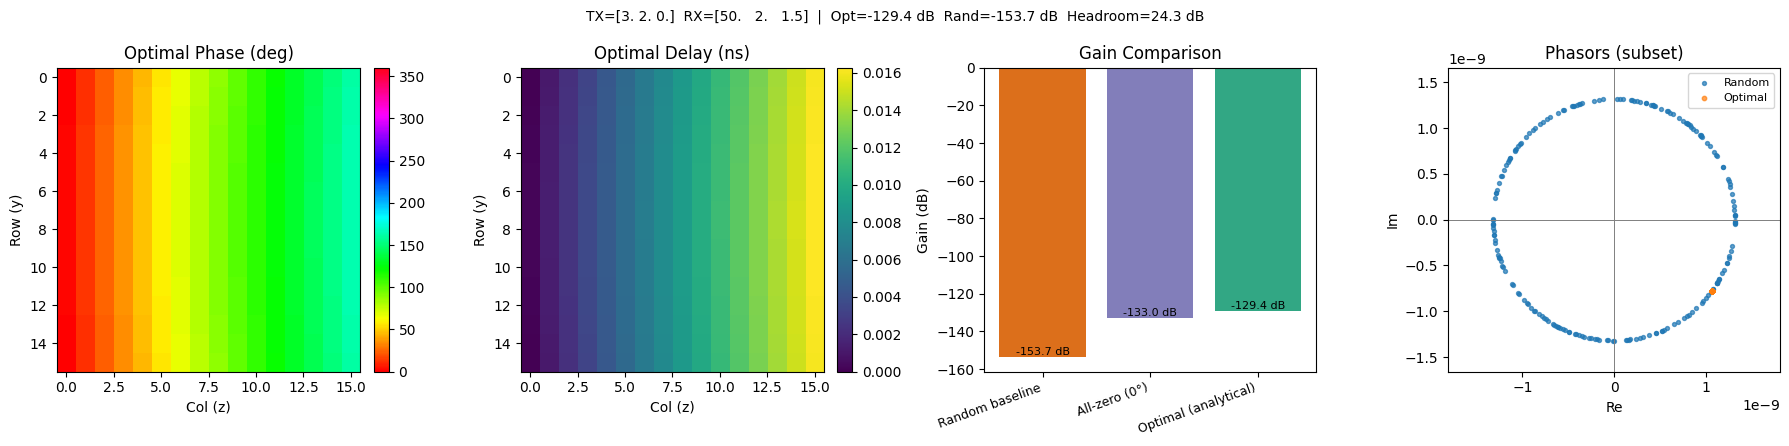

All-zero gain  : -132.99 dB
Random baseline: -153.70 dB
Optimal        : -129.43 dB
Headroom       : 24.27 dB


In [ ]:
# ===== Channel sanity check — visualise optimal phase map for one geometry =====

TX_EX = np.array([3.0, 2.0, 0.0])
RX_EX = np.array([50.0, 2.0, 1.5])
rng_vis = np.random.default_rng(0)

tau_na_ex, tau_nb_ex, alpha_ex, beta_ex, tau_opt_ex, phi_opt_deg_ex, gain_opt_ex = \
    compute_channel(TX_EX, RX_EX)

gain_rand_ex  = random_gain(tau_na_ex, tau_nb_ex, alpha_ex, beta_ex, rng_vis, n_samples=50)
gain_zeros_ex = channel_gain(tau_na_ex, tau_nb_ex, alpha_ex, beta_ex, np.zeros(N))

phi_map    = (phi_opt_deg_ex % 360).reshape(Ny, Nz)
tau_map_ns = (tau_opt_ex * 1e9).reshape(Ny, Nz)

vals_db = [
    10 * np.log10(gain_rand_ex  + 1e-20),
    10 * np.log10(gain_zeros_ex + 1e-20),
    10 * np.log10(gain_opt_ex   + 1e-20),
]
labels = ['Random baseline', 'All-zero (0°)', 'Optimal (analytical)']

sample_n = min(200, N)
idx = rng_vis.choice(np.arange(N), size=sample_n, replace=False)
tau_rand = rng_vis.uniform(0, 1 / fc, N)
amp = np.sqrt(alpha_ex * beta_ex)
phasor_opt  = amp[idx] * np.exp(-1j * 2*np.pi*fc * (tau_na_ex[idx] + tau_opt_ex[idx] + tau_nb_ex[idx]))
phasor_rand = amp[idx] * np.exp(-1j * 2*np.pi*fc * (tau_na_ex[idx] + tau_rand[idx]   + tau_nb_ex[idx]))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

im1 = axes[0].imshow(phi_map, cmap='hsv', vmin=0, vmax=360, aspect='auto')
axes[0].set_title('Optimal Phase (deg)')
axes[0].set_xlabel('Col (z)'); axes[0].set_ylabel('Row (y)')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(tau_map_ns, cmap='viridis', aspect='auto')
axes[1].set_title('Optimal Delay (ns)')
axes[1].set_xlabel('Col (z)'); axes[1].set_ylabel('Row (y)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

colors = ['#d95f02', '#7570b3', '#1b9e77']
bars = axes[2].bar(np.arange(3), vals_db, color=colors, alpha=0.9)
axes[2].set_xticks(np.arange(3), labels, rotation=20, ha='right', fontsize=9)
axes[2].set_ylabel('Gain (dB)'); axes[2].set_title('Gain Comparison')
for b in bars:
    axes[2].text(
        b.get_x() + b.get_width() / 2, b.get_height(),
        f'{b.get_height():.1f} dB', ha='center', va='bottom', fontsize=8
    )

axes[3].scatter(phasor_rand.real, phasor_rand.imag, s=8,  alpha=0.7, label='Random')
axes[3].scatter(phasor_opt.real,  phasor_opt.imag,  s=10, alpha=0.7, label='Optimal')
axes[3].set_title('Phasors (subset)'); axes[3].set_xlabel('Re'); axes[3].set_ylabel('Im')
axes[3].axhline(0, color='gray', lw=0.7); axes[3].axvline(0, color='gray', lw=0.7)
axes[3].axis('equal'); axes[3].legend(fontsize=8)

headroom_check = 10*np.log10(gain_opt_ex+1e-20) - 10*np.log10(gain_rand_ex+1e-20)
plt.suptitle(
    f'TX={TX_EX}  RX={RX_EX}  |  '
    f'Opt={vals_db[2]:.1f} dB  Rand={vals_db[0]:.1f} dB  '
    f'Headroom={headroom_check:.1f} dB',
    fontsize=10,
)
plt.tight_layout()
plt.show()
print(f'All-zero gain  : {vals_db[1]:.2f} dB')
print(f'Random baseline: {vals_db[0]:.2f} dB')
print(f'Optimal        : {vals_db[2]:.2f} dB')
print(f'Headroom       : {headroom_check:.2f} dB')

In [ ]:
# ===== Training =====

UPDATES       = 3000    # N_PASSES=3 → T=12 steps, wider dist, noise — more budget
ROLLOUT_STEPS = 2048
LOG_EVERY     = 20
EVAL_EPISODES = 200
TRAIN_SEED    = 42
EVAL_SEED     = 999
LR            = 1e-4    # reduced from 3e-4 — less aggressive per-step updates
NOISE_LEVEL   = 0.1   # multiplicative gain noise ~SNR=20dB — realistic mmWave

cfg = {
    'gamma':        0.99,
    'gae_lambda':   0.95,
    'clip_eps':     0.2,
    'entropy_coef': 0.05,   # increased from 0.02 — keep policy exploratory longer
    'value_coef':   0.5,    # reduced from 1.0 — less value loss dominance
    'grad_clip':    0.5,    # tightened from 1.0 — prevent large gradient steps
    'n_epochs_ppo': 4,      # reduced from 8 — fewer epochs per rollout avoids premature collapse
    'batch_size':   128,
}

np.random.seed(TRAIN_SEED)
torch.manual_seed(TRAIN_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_env = RISEnv(seed=TRAIN_SEED, noise_level=NOISE_LEVEL)
ac = ActorCritic(train_env.state_dim, train_env.n_actions).to(device)
optimiser = torch.optim.Adam(ac.parameters(), lr=LR)
buffer = RolloutBuffer(ROLLOUT_STEPS, train_env.state_dim)

history = {
    'update':       [],
    'eval_reward':  [],
    'pct_optimal':  [],
    'policy_loss':  [],
    'value_loss':   [],
    'entropy':      [],
}

state = train_env.reset()
t_start = time.time()

print('Training config')
print(f'  Updates        : {UPDATES}')
print(f'  Steps/update   : {ROLLOUT_STEPS}')
print(f'  Total steps    : {UPDATES * ROLLOUT_STEPS:,}')
print(f'  Eval episodes  : {EVAL_EPISODES}')
print(f'  State dim      : {train_env.state_dim}  (non-oracle)')
print(f'  Device         : {device}')
print()
print(
    f"{'Update':>7}  {'Steps':>9}  {'EvalR':>7}  {'%Opt':>7}  "
    f"{'PiLoss':>8}  {'ValLoss':>8}  {'Entropy':>8}  {'Time':>6}"
)
print('-' * 90)

for update in range(1, UPDATES + 1):
    buffer.reset()

    for _ in range(ROLLOUT_STEPS):
        s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action, log_prob, value, _ = ac.act(s_t)
        a = action.item()
        next_state, reward, done, _ = train_env.step(a)
        buffer.store(state, a, reward, value.item(), log_prob.item(), float(done))
        state = train_env.reset() if done else next_state

    with torch.no_grad():
        s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        _, _, last_v, _ = ac.act(s_t)
        last_value = last_v.item()

    metrics = ppo_update(ac, optimiser, buffer, last_value, cfg, device)

    if update % LOG_EVERY == 0:
        eval_r, pct_opt = evaluate(
            ac, device,
            n_episodes=EVAL_EPISODES,
            seed=EVAL_SEED,
            noise_level=NOISE_LEVEL,
        )
        elapsed = time.time() - t_start

        history['update'].append(update)
        history['eval_reward'].append(eval_r)
        history['pct_optimal'].append(pct_opt)
        history['policy_loss'].append(metrics['policy_loss'])
        history['value_loss'].append(metrics['value_loss'])
        history['entropy'].append(metrics['entropy'])

        print(
            f"{update:>7}  {update * ROLLOUT_STEPS:>9,}  {eval_r:>7.3f}  {pct_opt:>6.1f}%  "
            f"{metrics['policy_loss']:>8.4f}  {metrics['value_loss']:>8.4f}  "
            f"{metrics['entropy']:>8.4f}  {elapsed:>5.0f}s"
        )

Training config
  Updates        : 3000
  Steps/update   : 2048
  Total steps    : 6,144,000
  Eval episodes  : 200
  State dim      : 14  (non-oracle)
  Device         : cuda

 Update      Steps    EvalR     %Opt    PiLoss   ValLoss   Entropy    Time
------------------------------------------------------------------------------------------
     20     40,960    3.781    31.7%   -0.0025    0.9547    1.9016     70s
     40     81,920    4.416    35.0%   -0.0082    0.4360    1.7521    138s
     60    122,880    4.547    36.1%   -0.0049    0.3319    1.7206    206s
     80    163,840    4.500    37.0%   -0.0049    0.3173    1.3301    274s
    100    204,800    4.515    34.3%   -0.0084    0.3200    1.5707    341s
    120    245,760    4.564    35.6%   -0.0073    0.3279    1.4363    408s
    140    286,720    4.546    36.0%   -0.0072    0.3028    1.4659    476s
    160    327,680    4.520    37.2%   -0.0055    0.3404    1.5282    542s
    180    368,640    4.566    35.7%   -0.0059    0.3062 

Model saved locally : /content/ppo_train/ppo_model_noisy.pt
Model saved to Drive: /content/drive/MyDrive/ppo_train/ppo_model_noisy.pt


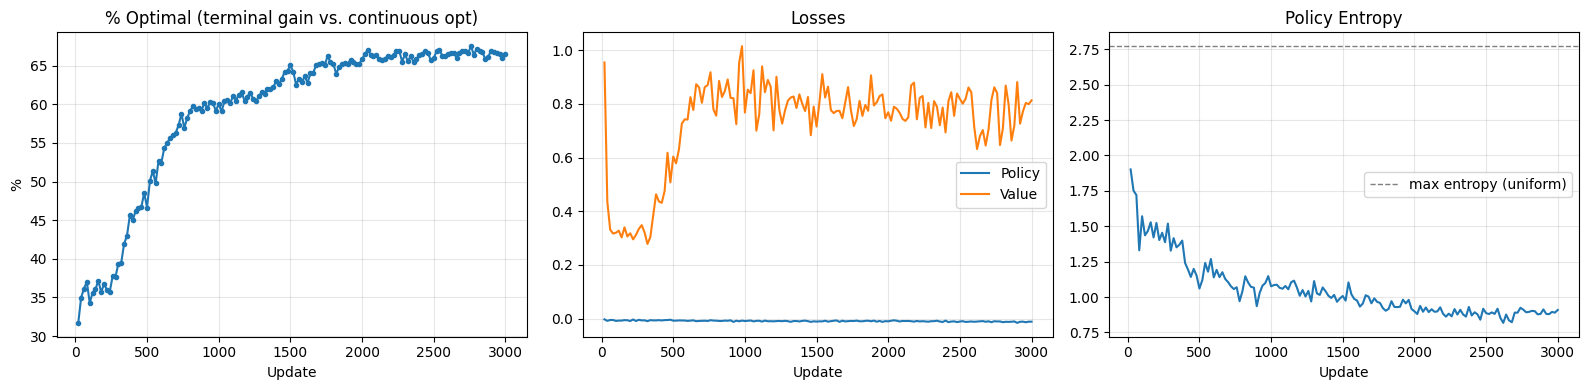

Plot saved  locally : /content/ppo_train/ppo_training_noisy.png
Plot saved to Drive : /content/drive/MyDrive/ppo_train/ppo_training_noisy.png


In [ ]:


outdir       = '/content/ppo_train'
outdir_drive = '/content/drive/MyDrive/ppo_train'
os.makedirs(outdir,       exist_ok=True)
os.makedirs(outdir_drive, exist_ok=True)

model_path       = os.path.join(outdir,       'ppo_model_noisy.pt')
model_path_drive = os.path.join(outdir_drive, 'ppo_model_noisy.pt')
plot_path        = os.path.join(outdir,       'ppo_training_noisy.png')
plot_path_drive  = os.path.join(outdir_drive, 'ppo_training_noisy.png')

checkpoint = {
    'ac_state_dict':           ac.state_dict(),
    'optimiser_state_dict':    optimiser.state_dict(),
    'history':                 history,
    'config': {
        'state_dim':     STATE_DIM,
        'obs_mode':      'non-oracle (phase+gain+step+group)',
        'noise_level':   NOISE_LEVEL,
        'updates':       UPDATES,
        'rollout_steps': ROLLOUT_STEPS,
        'eval_episodes': EVAL_EPISODES,
        'train_seed':    TRAIN_SEED,
        'eval_seed':     EVAL_SEED,
        'lr':            LR,
        **cfg,
    },
}
torch.save(checkpoint, model_path)
torch.save(checkpoint, model_path_drive)
print(f'Model saved locally : {model_path}')
print(f'Model saved to Drive: {model_path_drive}')

if history['update']:
    updates = history['update']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(updates, history['pct_optimal'], marker='o', markersize=3)
    axes[0].set_title('% Optimal (terminal gain vs. continuous opt)')
    axes[0].set_xlabel('Update'); axes[0].set_ylabel('%')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(updates, history['policy_loss'], label='Policy')
    axes[1].plot(updates, history['value_loss'],  label='Value')
    axes[1].set_title('Losses')
    axes[1].set_xlabel('Update'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(updates, history['entropy'])
    axes[2].axhline(np.log(n_actions), linestyle='--', lw=1.0, color='gray',
                    label='max entropy (uniform)')
    axes[2].set_title('Policy Entropy')
    axes[2].set_xlabel('Update'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

import shutil
shutil.copy(plot_path, plot_path_drive)
print(f'Plot saved  locally : {plot_path}')
print(f'Plot saved to Drive : {plot_path_drive}')

In [ ]:
# ===== Inference on one fixed geometry =====
# Loads the model from Google Drive so you can run this cell independently
# without retraining.  Falls back to the in-memory `ac` if Drive model not found.
# Benchmarks: random, all-zero start, discrete ceiling (K^G brute-force), PPO.

FIX_TX = np.array([2.0, 1.0, -0.5])
FIX_RX = np.array([52.0, 3.0,  2.0])

#FIX_TX = np.array([1.0, 1.0, -0.5])   # TX min corner
#FIX_RX = np.array([55.0, 1.0, -2.0])  # RX far corner

#FIX_TX = np.array([3.0, 2.0,  0.0])
#FIX_RX = np.array([50.0, 2.0, 0.0])   # same y/z as TX


INFER_SEED = 999
# ── Load model ──────────────────────────────────────────────────────────
DRIVE_MODEL = '/content/drive/MyDrive/ppo_train/ppo_model_noisy.pt'
LOCAL_MODEL = '/content/ppo_train/ppo_model_noisy.pt'

def load_ac(path, device):
    ckpt = torch.load(path, map_location=device)
    _ac  = ActorCritic(STATE_DIM, n_actions).to(device)
    _ac.load_state_dict(ckpt['ac_state_dict'])
    _ac.eval()
    print(f'Loaded model from: {path}')
    cfg_saved = ckpt.get('config', {})
    print(f'  trained for {cfg_saved.get("updates", "?")!r} updates, '
          f'obs_mode={cfg_saved.get("obs_mode", "?")!r}')
    return _ac

# Try Drive first, then local, then fall back to in-memory ac
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ac_infer = load_ac(DRIVE_MODEL, device)
except Exception:
    try:
        ac_infer = load_ac(LOCAL_MODEL, device)
    except Exception as e:
        print(f'Could not load model: {e}')
        raise RuntimeError('Run Cell 4 (training) first, or ensure ppo_model_noisy.pt exists in Drive.')


def true_discrete_ceiling(tau_na, tau_nb, alpha_ch, beta_ch):
    """Brute-force the best K^G = 65 536 grouped discrete configurations."""
    best_gain = -np.inf
    best_k    = None
    for a0 in range(K):
        for a1 in range(K):
            for a2 in range(K):
                for a3 in range(K):
                    cand = np.array([a0, a1, a2, a3], dtype=int)
                    g = channel_gain(
                        tau_na, tau_nb, alpha_ch, beta_ch,
                        config_to_tau(phase_levels_deg[cand]),
                    )
                    if g > best_gain:
                        best_gain = g
                        best_k    = cand.copy()
    return float(best_gain), best_k


def pct_of_opt(gain_lin, rand_lin, opt_lin):
    """All arguments are linear gains (not dB)."""
    return (gain_lin - rand_lin) / ((opt_lin - rand_lin) + 1e-30) * 100.0


# --- Channel for the fixed geometry ---
rng_inf = np.random.default_rng(INFER_SEED)
tau_na_f, tau_nb_f, alpha_f, beta_f, tau_opt_f, phi_opt_f, gain_opt_f = \
    compute_channel(FIX_TX, FIX_RX)
gain_rand_f  = random_gain(tau_na_f, tau_nb_f, alpha_f, beta_f, rng_inf, n_samples=100)
gain_zeros_f = channel_gain(tau_na_f, tau_nb_f, alpha_f, beta_f, np.zeros(N))

opt_db   = 10 * np.log10(gain_opt_f   + 1e-20)
rand_db  = 10 * np.log10(gain_rand_f  + 1e-20)
zeros_db = 10 * np.log10(gain_zeros_f + 1e-20)

print('Computing discrete ceiling (K^G = 65 536 configs)…', end=' ', flush=True)
gain_ceil_f, k_ceil = true_discrete_ceiling(tau_na_f, tau_nb_f, alpha_f, beta_f)
ceil_db = 10 * np.log10(gain_ceil_f + 1e-20)
print('done.')

# --- Build inference env with fixed geometry ---
infer_env = RISEnv(seed=INFER_SEED, noise_level=NOISE_LEVEL)
infer_env.tau_na   = tau_na_f
infer_env.tau_nb   = tau_nb_f
infer_env.alpha_ch = alpha_f
infer_env.beta_ch  = beta_f
infer_env.gain_opt = gain_opt_f
infer_env.gain_rand = gain_rand_f
infer_env.group_phases = np.zeros(G, dtype=int)   # start at 0°
infer_env.group_order  = list(range(G))            # fixed for reproducible inference
infer_env.gain_prev    = infer_env._gain(phase_levels_deg[infer_env.group_phases])
infer_env.gain_init    = infer_env.gain_prev
infer_env.step_count   = 0
state = infer_env._get_state()

# --- Random baseline: run T random actions, average over 200 episodes ---
print('Computing random baseline (200 episodes)...', end=' ', flush=True)
rng_rand_bl = np.random.default_rng(INFER_SEED + 1)
_rand_pcts = []
for _ in range(200):
    _env = RISEnv(seed=int(rng_rand_bl.integers(1e6)), noise_level=NOISE_LEVEL)
    _env.tau_na = tau_na_f; _env.tau_nb = tau_nb_f
    _env.alpha_ch = alpha_f; _env.beta_ch = beta_f
    _env.gain_opt = gain_opt_f; _env.gain_rand = gain_rand_f
    _env.group_phases = np.zeros(G, dtype=int)
    _env.group_order  = rng_rand_bl.permutation(G).tolist()
    _env.gain_prev = _env._gain(phase_levels_deg[_env.group_phases])
    _env.gain_init = _env.gain_prev; _env.step_count = 0
    for _ in range(T):
        _a = rng_rand_bl.integers(0, K)
        _, _, _done, _info = _env.step(int(_a))
        if _done: break
    _rand_pcts.append(_info['pct_optimal'])
rand_policy_pct  = float(np.mean(_rand_pcts))
rand_policy_gain = gain_rand_f + rand_policy_pct / 100 * (gain_opt_f - gain_rand_f)
rand_policy_db   = 10 * np.log10(rand_policy_gain + 1e-20)
print('done.')

print('=' * 70)
print('Fixed-Geometry Inference')
print(f'  TX         : {FIX_TX}')
print(f'  RX         : {FIX_RX}')
print(f'  Obs mode   : non-oracle')
print('-' * 70)
print(f'  Random phase baseline   : {rand_db:.2f} dB')
print(f'  Random policy baseline  : {rand_policy_db:.2f} dB  ({rand_policy_pct:.1f}% opt)')
print(f'  Initial gain (0°)       : {zeros_db:.2f} dB  ({pct_of_opt(gain_zeros_f, gain_rand_f, gain_opt_f):.1f}% opt)')
print(f'  Discrete ceiling        : {ceil_db:.2f} dB  ({pct_of_opt(gain_ceil_f, gain_rand_f, gain_opt_f):.1f}% opt)')
print(f'  Continuous optimal      : {opt_db:.2f} dB')
print(f'  Ceiling phases (k)      : {k_ceil.tolist()}')
print(f'  Ceiling phases (°)      : {phase_levels_deg[k_ceil]}')
print()
print(f"  {'Step':>4}  {'Group':>5}  {'Phase':>7}  {'Gain(dB)':>10}  {'Reward':>8}  {'%Opt':>7}")

ep_r = 0.0
with torch.no_grad():
    for _ in range(T):
        s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits, _ = ac_infer(s_t)
        action = logits.argmax(dim=1).item()
        state, reward, done, info = infer_env.step(action)
        ep_r += reward
        print(
            f"  {info['step']:>4}  {info['group']:>5}  "
            f"{info['phase_deg']:>6.0f}°  "
            f"{info['gain_db']:>10.2f}  "
            f"{reward:>8.4f}  "
            f"{info['pct_optimal']:>6.1f}%"
        )
        if done:
            break

ppo_db  = info['gain_db']
gain_ppo = infer_env.gain_prev   # linear gain after last step
pct_ppo_vs_cont  = pct_of_opt(gain_ppo,    gain_rand_f, gain_opt_f)
pct_ceil_vs_cont = pct_of_opt(gain_ceil_f, gain_rand_f, gain_opt_f)
pct_ppo_vs_ceil  = (gain_ppo - gain_rand_f) / ((gain_ceil_f - gain_rand_f) + 1e-30) * 100.0

print('-' * 70)
pct_rand_vs_ceil = (rand_policy_gain - gain_rand_f) / ((gain_ceil_f - gain_rand_f) + 1e-30) * 100
print(f'  Total episode reward    : {ep_r:.4f}')
print(f'  --- Baselines ---')
print(f'  Random phase            : {rand_db:.2f} dB  (0% opt)')
print(f'  Random policy           : {rand_policy_db:.2f} dB  ({rand_policy_pct:.1f}% opt,  {pct_rand_vs_ceil:.1f}% of ceiling)')
print(f'  --- PPO ---')
print(f'  Final %Opt (vs cont.)   : {pct_ppo_vs_cont:.1f}%')
print(f'  Ceiling %Opt (vs cont.) : {pct_ceil_vs_cont:.1f}%')
print(f'  PPO as % of ceiling     : {pct_ppo_vs_ceil:.1f}%')
print(f'  Gain gap to cont. opt   : {opt_db  - ppo_db:.2f} dB')
print(f'  Gain gap to ceiling     : {ceil_db - ppo_db:.2f} dB')
print(f'  PPO vs random policy    : +{pct_ppo_vs_cont - rand_policy_pct:.1f}% opt gain')
print(f'  PPO phases (k)          : {infer_env.group_phases.tolist()}')
print(f'  PPO phases (°)          : {phase_levels_deg[infer_env.group_phases]}')
print('=' * 70)

Mounted at /content/drive
Loaded model from: /content/drive/MyDrive/ppo_train/ppo_model_noisy.pt
  trained for 3000 updates, obs_mode='non-oracle (phase+gain+step+group)'
Computing discrete ceiling (K^G = 65 536 configs)… done.
Computing random baseline (200 episodes)... done.
Fixed-Geometry Inference
  TX         : [ 2.   1.  -0.5]
  RX         : [52.  3.  2.]
  Obs mode   : non-oracle
----------------------------------------------------------------------
  Random phase baseline   : -154.10 dB
  Random policy baseline  : -136.49 dB  (24.9% opt)
  Initial gain (0°)       : -133.18 dB  (53.8% opt)
  Discrete ceiling        : -130.73 dB  (95.0% opt)
  Continuous optimal      : -130.51 dB
  Ceiling phases (k)      : [10, 12, 13, 15]
  Ceiling phases (°)      : [225.  270.  292.5 337.5]

  Step  Group    Phase    Gain(dB)    Reward     %Opt
     1      0       0°     -133.18    0.5384    53.8%
     2      1       0°     -133.18    0.5384    53.8%
     3      2     315°     -134.57    0.389

Sweeping RX grid:   0%|          | 0/221 [00:00<?, ?it/s]

Sweep complete.


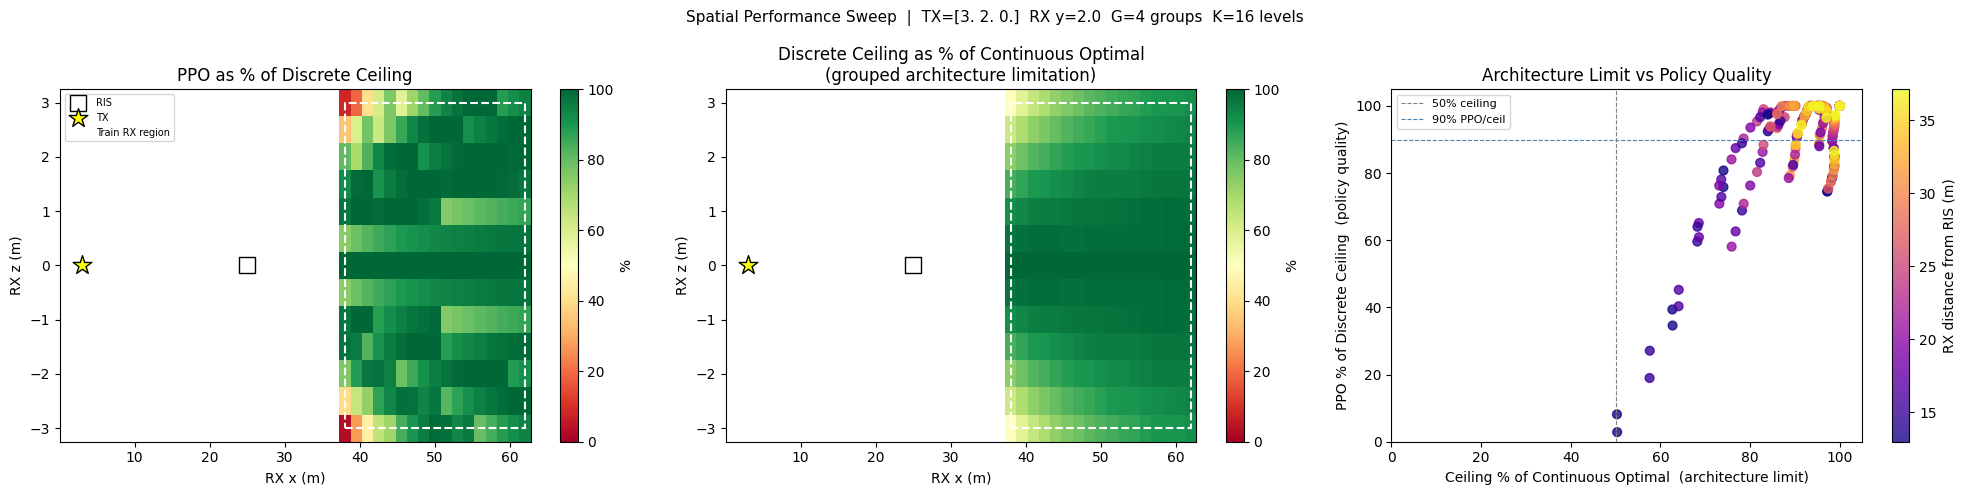

Saved: /content/ppo_train/spatial_sweep.png


In [ ]:
# ===== Spatial Performance Heatmap =====
# Run after training. Sweeps RX over a 2D grid, runs PPO inference at each point.
# Produces: (1) 2D heatmaps of PPO%ceiling and ceiling%opt
#           (2) Scatter of ceiling%opt vs PPO%ceiling coloured by RX distance

import itertools
from tqdm.auto import tqdm

# --- Sweep config ---
FIX_TX      = np.array([3.0, 2.0, 0.0])
RX_Y_FIXED  = 2.0                          # fix RX y, sweep x and z
RX_X_VALS   = np.linspace(38, 62, 17)      # 17 points across x
RX_Z_VALS   = np.linspace(-3, 3, 13)       # 13 points across z
SWEEP_SEED  = 777
N_RAND_SAMPLES = 50                        # for gain_rand estimate

# Training distribution boundaries (for overlay rectangle)
TRAIN_RX_X = (38, 62)   # was (45, 55)
TRAIN_RX_Z = (-3, 3)    # was (-2, 2)

device_sw = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ac_infer.eval()

# --- Storage ---
nx, nz = len(RX_X_VALS), len(RX_Z_VALS)
grid_ppo_pct_ceil  = np.full((nz, nx), np.nan)  # PPO % of ceiling
grid_ceil_pct_cont = np.full((nz, nx), np.nan)  # ceiling % of continuous opt
grid_ppo_pct_cont  = np.full((nz, nx), np.nan)  # PPO % of continuous opt
grid_headroom_db   = np.full((nz, nx), np.nan)  # opt - rand in dB (geometry difficulty)

rng_sw = np.random.default_rng(SWEEP_SEED)

total = nx * nz
pbar = tqdm(total=total, desc='Sweeping RX grid')

for ix, rx_x in enumerate(RX_X_VALS):
    for iz, rx_z in enumerate(RX_Z_VALS):

        rx = np.array([rx_x, RX_Y_FIXED, rx_z])

        # Channel
        tau_na_s, tau_nb_s, alpha_s, beta_s, _, _, gain_opt_s = compute_channel(FIX_TX, rx)
        gain_rand_s  = random_gain(tau_na_s, tau_nb_s, alpha_s, beta_s, rng_sw, n_samples=N_RAND_SAMPLES)

        # Discrete ceiling (brute force K^G)
        gain_ceil_s, _ = true_discrete_ceiling(tau_na_s, tau_nb_s, alpha_s, beta_s)

        # PPO inference
        env_s = RISEnv(seed=SWEEP_SEED, noise_level=0.0)
        env_s.tau_na    = tau_na_s
        env_s.tau_nb    = tau_nb_s
        env_s.alpha_ch  = alpha_s
        env_s.beta_ch   = beta_s
        env_s.gain_opt  = gain_opt_s
        env_s.gain_rand = gain_rand_s
        env_s.group_phases = np.zeros(G, dtype=int)
        env_s.gain_prev    = env_s._gain(phase_levels_deg[env_s.group_phases])
        env_s.gain_init    = env_s.gain_prev
        env_s.step_count   = 0
        state_s = env_s._get_state()

        with torch.no_grad():
            for _ in range(T):
                st = torch.FloatTensor(state_s).unsqueeze(0).to(device_sw)
                logits, _ = ac_infer(st)
                action = logits.argmax(dim=1).item()
                state_s, _, done, info_s = env_s.step(action)
                if done:
                    break

        gain_ppo_s = env_s.gain_prev  # linear, after last step

        # Metrics (linear scale)
        headroom_lin = (gain_opt_s  - gain_rand_s) + 1e-30
        headroom_ceil = (gain_ceil_s - gain_rand_s) + 1e-30

        ppo_pct_cont  = (gain_ppo_s  - gain_rand_s) / headroom_lin  * 100
        ceil_pct_cont = (gain_ceil_s - gain_rand_s) / headroom_lin  * 100
        ppo_pct_ceil  = (gain_ppo_s  - gain_rand_s) / headroom_ceil * 100

        opt_db  = 10 * np.log10(gain_opt_s  + 1e-20)
        rand_db = 10 * np.log10(gain_rand_s + 1e-20)

        grid_ppo_pct_ceil[iz, ix]  = ppo_pct_ceil
        grid_ceil_pct_cont[iz, ix] = ceil_pct_cont
        grid_ppo_pct_cont[iz, ix]  = ppo_pct_cont
        grid_headroom_db[iz, ix]   = opt_db - rand_db

        pbar.update(1)

pbar.close()
print('Sweep complete.')

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

XX_grid, ZZ_grid = np.meshgrid(RX_X_VALS, RX_Z_VALS)

def add_overlays(ax):
    # RIS position projected onto x-z plane
    ax.scatter([ris_x], [ris_z], marker='s', s=120, c='white',
               edgecolors='black', zorder=5, label='RIS')
    # TX
    ax.scatter([FIX_TX[0]], [FIX_TX[2]], marker='*', s=200, c='yellow',
               edgecolors='black', zorder=5, label='TX')
    # Training distribution rectangle
    rect = plt.Rectangle(
        (TRAIN_RX_X[0], TRAIN_RX_Z[0]),
        TRAIN_RX_X[1] - TRAIN_RX_X[0],
        TRAIN_RX_Z[1] - TRAIN_RX_Z[0],
        linewidth=1.5, edgecolor='white', facecolor='none',
        linestyle='--', label='Train RX region',
    )
    ax.add_patch(rect)
    ax.set_xlabel('RX x (m)')
    ax.set_ylabel('RX z (m)')

# 1. PPO % of discrete ceiling
im0 = axes[0].pcolormesh(XX_grid, ZZ_grid, grid_ppo_pct_ceil,
                          cmap='RdYlGn', vmin=0, vmax=100, shading='auto')
plt.colorbar(im0, ax=axes[0], label='%')
axes[0].set_title('PPO as % of Discrete Ceiling')
add_overlays(axes[0])
axes[0].legend(fontsize=7, loc='upper left')

# 2. Ceiling % of continuous optimal
im1 = axes[1].pcolormesh(XX_grid, ZZ_grid, grid_ceil_pct_cont,
                          cmap='RdYlGn', vmin=0, vmax=100, shading='auto')
plt.colorbar(im1, ax=axes[1], label='%')
axes[1].set_title('Discrete Ceiling as % of Continuous Optimal\n(grouped architecture limitation)')
add_overlays(axes[1])

# 3. Scatter: ceiling%opt vs PPO%ceiling, coloured by RX distance from RIS
rx_dist = np.sqrt((XX_grid - ris_x)**2 + (ZZ_grid - ris_z)**2).ravel()
sc = axes[2].scatter(
    grid_ceil_pct_cont.ravel(),
    grid_ppo_pct_ceil.ravel(),
    c=rx_dist, cmap='plasma', s=40, alpha=0.8,
)
plt.colorbar(sc, ax=axes[2], label='RX distance from RIS (m)')
axes[2].axvline(x=50, color='gray', linestyle='--', linewidth=0.8, label='50% ceiling')
axes[2].axhline(y=90, color='steelblue', linestyle='--', linewidth=0.8, label='90% PPO/ceil')
axes[2].set_xlabel('Ceiling % of Continuous Optimal  (architecture limit)')
axes[2].set_ylabel('PPO % of Discrete Ceiling  (policy quality)')
axes[2].set_title('Architecture Limit vs Policy Quality')
axes[2].set_xlim(0, 105); axes[2].set_ylim(0, 105)
axes[2].legend(fontsize=8)

plt.suptitle(
    f'Spatial Performance Sweep  |  TX={FIX_TX}  RX y={RX_Y_FIXED}  '
    f'G={G} groups  K={K} levels',
    fontsize=11,
)
plt.tight_layout()

sweep_plot_path = '/content/ppo_train/spatial_sweep.png'
plt.savefig(sweep_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {sweep_plot_path}')

Sweeping RX grid:   0%|          | 0/221 [00:00<?, ?it/s]

Sweep complete.


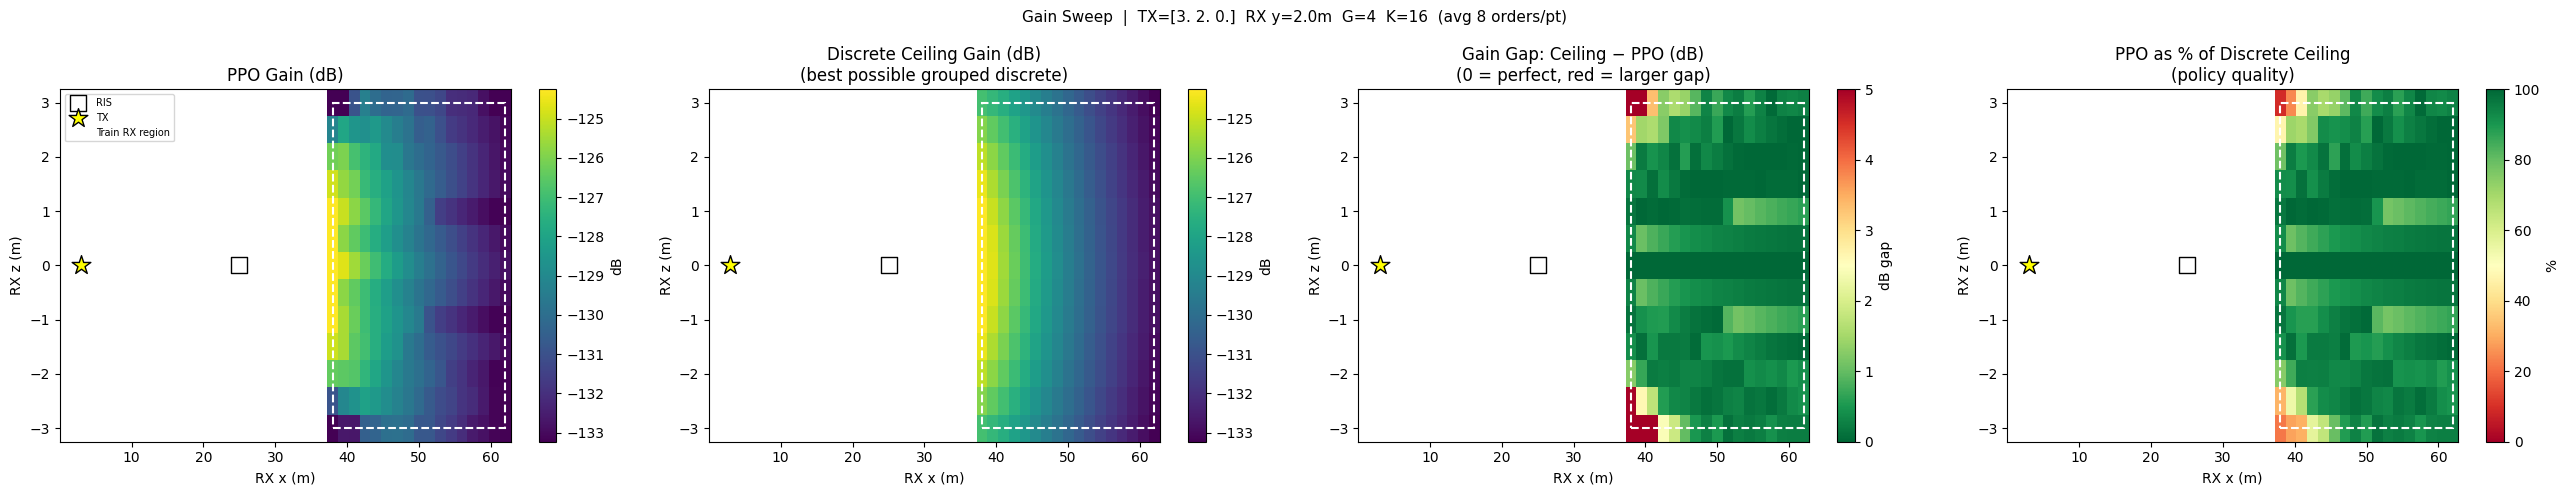

Saved: /content/ppo_train/gain_sweep.png


In [ ]:
# ===== Spatial Gain Heatmaps — PPO vs Discrete Ceiling (dB) =====
# Shows absolute gain in dB across the sweep grid for:
#   (1) PPO agent
#   (2) Discrete ceiling (brute-force best)
#   (3) Gain gap: ceiling - PPO  (how much is left on the table)

from tqdm.auto import tqdm

# --- Sweep config ---
FIX_TX          = np.array([3.0, 2.0, 0.0])
RX_Y_FIXED      = 2.0
RX_X_VALS       = np.linspace(38, 62, 17)
RX_Z_VALS       = np.linspace(-3, 3, 13)
SWEEP_SEED      = 777
N_RAND_SAMPLES  = 100
N_ORDER_SAMPLES = 8

TRAIN_RX_X = (38, 62)   # matches v8_newtrain
TRAIN_RX_Z = (-3, 3)

device_sw = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ac_infer.eval()

nx, nz = len(RX_X_VALS), len(RX_Z_VALS)
grid_ppo_db    = np.full((nz, nx), np.nan)   # PPO gain in dB
grid_ceil_db   = np.full((nz, nx), np.nan)   # Discrete ceiling gain in dB
grid_rand_db   = np.full((nz, nx), np.nan)   # Random baseline in dB
grid_gap_db    = np.full((nz, nx), np.nan)   # ceil_db - ppo_db
# also keep % metrics for scatter
grid_ppo_pct_ceil  = np.full((nz, nx), np.nan)
grid_ceil_pct_cont = np.full((nz, nx), np.nan)

rng_sw = np.random.default_rng(SWEEP_SEED)
pbar   = tqdm(total=nx * nz, desc='Sweeping RX grid')

for ix, rx_x in enumerate(RX_X_VALS):
    for iz, rx_z in enumerate(RX_Z_VALS):

        rx = np.array([rx_x, RX_Y_FIXED, rx_z])

        tau_na_s, tau_nb_s, alpha_s, beta_s, _, _, gain_opt_s = compute_channel(FIX_TX, rx)
        gain_rand_s = random_gain(tau_na_s, tau_nb_s, alpha_s, beta_s,
                                  rng_sw, n_samples=N_RAND_SAMPLES)
        gain_ceil_s, _ = true_discrete_ceiling(tau_na_s, tau_nb_s, alpha_s, beta_s)

        # PPO inference — avg over random group orders
        gain_ppo_samples = []
        for _ in range(N_ORDER_SAMPLES):
            env_s = RISEnv(seed=SWEEP_SEED, noise_level=0.0)
            env_s.tau_na       = tau_na_s
            env_s.tau_nb       = tau_nb_s
            env_s.alpha_ch     = alpha_s
            env_s.beta_ch      = beta_s
            env_s.gain_opt     = gain_opt_s
            env_s.gain_rand    = gain_rand_s
            env_s.group_phases = np.zeros(G, dtype=int)
            env_s.group_order  = rng_sw.permutation(G).tolist()
            env_s.gain_prev    = env_s._gain(phase_levels_deg[env_s.group_phases])
            env_s.gain_init    = env_s.gain_prev
            env_s.step_count   = 0
            state_s            = env_s._get_state()

            with torch.no_grad():
                for _ in range(T):
                    st = torch.FloatTensor(state_s).unsqueeze(0).to(device_sw)
                    logits, _ = ac_infer(st)
                    action  = logits.argmax(dim=1).item()
                    state_s, _, done, _ = env_s.step(action)
                    if done:
                        break
            gain_ppo_samples.append(env_s.gain_prev)

        gain_ppo_s = float(np.mean(gain_ppo_samples))

        # Convert to dB
        ppo_db  = 10 * np.log10(gain_ppo_s  + 1e-20)
        ceil_db = 10 * np.log10(gain_ceil_s + 1e-20)
        rand_db = 10 * np.log10(gain_rand_s + 1e-20)
        opt_db  = 10 * np.log10(gain_opt_s  + 1e-20)

        grid_ppo_db[iz, ix]   = ppo_db
        grid_ceil_db[iz, ix]  = ceil_db
        grid_rand_db[iz, ix]  = rand_db
        grid_gap_db[iz, ix]   = ceil_db - ppo_db   # always >= 0

        headroom_lin  = (gain_opt_s  - gain_rand_s) + 1e-30
        headroom_ceil = (gain_ceil_s - gain_rand_s) + 1e-30
        grid_ppo_pct_ceil[iz, ix]  = (gain_ppo_s  - gain_rand_s) / headroom_ceil * 100
        grid_ceil_pct_cont[iz, ix] = (gain_ceil_s - gain_rand_s) / headroom_lin  * 100

        pbar.update(1)

pbar.close()
print('Sweep complete.')

# --- Shared colourscale for PPO and ceiling panels ---
all_db   = np.concatenate([grid_ppo_db.ravel(), grid_ceil_db.ravel()])
vmin_db  = np.nanpercentile(all_db, 2)   # robust min
vmax_db  = np.nanpercentile(all_db, 98)  # robust max

XX_grid, ZZ_grid = np.meshgrid(RX_X_VALS, RX_Z_VALS)

def add_overlays(ax, legend=False):
    ax.scatter([ris_x], [ris_z], marker='s', s=120, c='white',
               edgecolors='black', zorder=5, label='RIS')
    ax.scatter([FIX_TX[0]], [FIX_TX[2]], marker='*', s=200, c='yellow',
               edgecolors='black', zorder=5, label=f'TX')
    rect = plt.Rectangle(
        (TRAIN_RX_X[0], TRAIN_RX_Z[0]),
        TRAIN_RX_X[1] - TRAIN_RX_X[0],
        TRAIN_RX_Z[1] - TRAIN_RX_Z[0],
        linewidth=1.5, edgecolor='white', facecolor='none',
        linestyle='--', label='Train RX region',
    )
    ax.add_patch(rect)
    ax.set_xlabel('RX x (m)')
    ax.set_ylabel('RX z (m)')
    if legend:
        ax.legend(fontsize=7, loc='upper left')

fig, axes = plt.subplots(1, 4, figsize=(26, 5))

# 1. PPO gain (dB)
im0 = axes[0].pcolormesh(XX_grid, ZZ_grid, grid_ppo_db,
                          cmap='viridis', vmin=vmin_db, vmax=vmax_db, shading='auto')
plt.colorbar(im0, ax=axes[0], label='dB')
axes[0].set_title('PPO Gain (dB)')
add_overlays(axes[0], legend=True)

# 2. Discrete ceiling gain (dB) — same colorscale as PPO for direct comparison
im1 = axes[1].pcolormesh(XX_grid, ZZ_grid, grid_ceil_db,
                          cmap='viridis', vmin=vmin_db, vmax=vmax_db, shading='auto')
plt.colorbar(im1, ax=axes[1], label='dB')
axes[1].set_title('Discrete Ceiling Gain (dB)\n(best possible grouped discrete)')
add_overlays(axes[1])

# 3. Gain gap: ceiling - PPO (dB) — how much PPO leaves on the table
# Shared zero baseline, red = larger gap
im2 = axes[2].pcolormesh(XX_grid, ZZ_grid, grid_gap_db,
                          cmap='RdYlGn_r', vmin=0, vmax=5, shading='auto')
plt.colorbar(im2, ax=axes[2], label='dB gap')
axes[2].set_title('Gain Gap: Ceiling − PPO (dB)\n(0 = perfect, red = larger gap)')
add_overlays(axes[2])

# 4. PPO % of ceiling (policy quality) for reference
im3 = axes[3].pcolormesh(XX_grid, ZZ_grid, grid_ppo_pct_ceil,
                          cmap='RdYlGn', vmin=0, vmax=100, shading='auto')
plt.colorbar(im3, ax=axes[3], label='%')
axes[3].set_title('PPO as % of Discrete Ceiling\n(policy quality)')
add_overlays(axes[3])

plt.suptitle(
    f'Gain Sweep  |  TX={FIX_TX}  RX y={RX_Y_FIXED}m  '
    f'G={G}  K={K}  (avg {N_ORDER_SAMPLES} orders/pt)',
    fontsize=11,
)
plt.tight_layout()

os.makedirs('/content/ppo_train', exist_ok=True)
gain_sweep_path = '/content/ppo_train/gain_sweep.png'
plt.savefig(gain_sweep_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {gain_sweep_path}')

In [ ]:
gap = grid_ceil_db - grid_ppo_db
print(f'Min gap (ceil - PPO): {np.nanmin(gap):.3f} dB')
print(f'Points where PPO > ceiling: {(gap < 0).sum()}')

Min gap (ceil - PPO): 0.000 dB
Points where PPO > ceiling: 0
